# White Blood Cell Segmentation  
## K-Means vs Fuzzy C-Means

### Objective

The objective of this experiment is to compare **K-Means (hard clustering)** and **Fuzzy C-Means (soft clustering)** for White Blood Cell (WBC) nucleus segmentation.

We aim to:
- Segment the nucleus region
- Compare boundary smoothness
- Understand the difference between hard and soft clustering

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:0000:010:01


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz

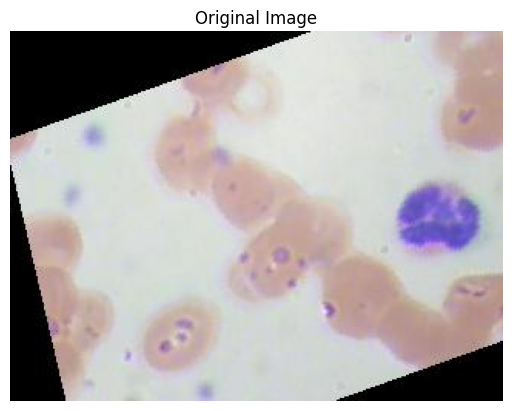

In [126]:
# img_path = "/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL/_0_207.jpeg"
# img_path = "/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL/_0_2370.jpeg"
# img_path = "/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE/_0_1511.jpeg"
img_path = "/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL/_0_4888.jpeg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Why Lab Color Space?

The image is converted from RGB to Lab color space.

- L channel → Lightness
- a channel → Green ↔ Red
- b channel → Blue ↔ Yellow

The WBC nucleus appears purple, which has strong red components. 
The 'a' channel helps better separate the nucleus from cytoplasm and background.

In [127]:
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

# Reshape pixels
pixels = lab.reshape((-1,3))
pixels = np.float32(pixels)

# K-Means Segmentation (Hard Clustering)
K-Means assigns each pixel strictly to one cluster.

Characteristics:
- Each pixel belongs to only one cluster
- Produces sharp boundaries
- Computationally fast

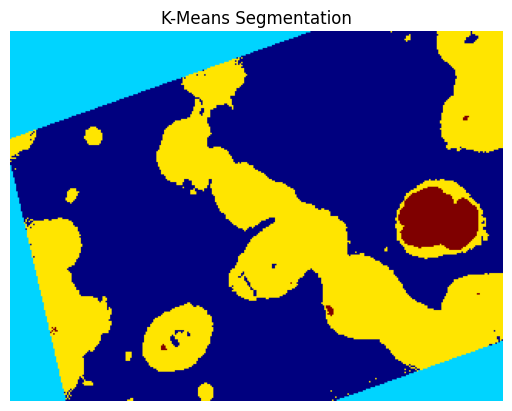

In [128]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(pixels)

segmented_kmeans = labels_kmeans.reshape(lab.shape[:2])

plt.imshow(segmented_kmeans, cmap="jet")
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()

Nucleus cluster: 3


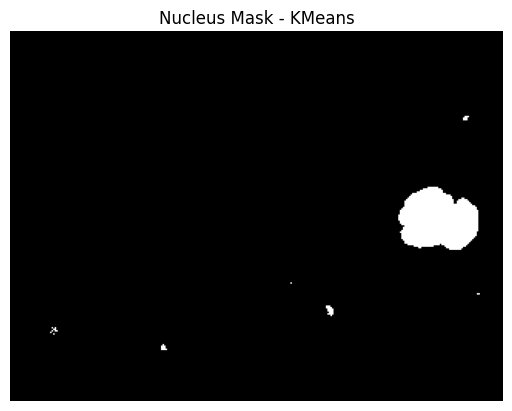

In [129]:
cluster_a_means = []

for i in range(4):
    cluster_a_means.append(
        np.mean(lab[:,:,1][segmented_kmeans == i])
    )

nucleus_cluster = np.argmax(cluster_a_means)

print("Nucleus cluster:", nucleus_cluster)

nucleus_mask_kmeans = (segmented_kmeans == nucleus_cluster)

plt.imshow(nucleus_mask_kmeans, cmap="gray")
plt.title("Nucleus Mask - KMeans")
plt.axis("off")
plt.show()

# Fuzzy C-Means Segmentation (Soft Clustering)

Fuzzy C-Means assigns membership probabilities to each cluster.

Characteristics:
- A pixel can partially belong to multiple clusters
- Produces smoother boundaries
- Better handles uncertainty at edges

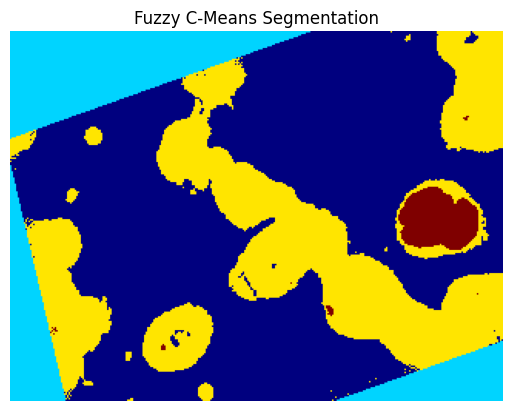

In [130]:
# Transpose required for FCM
pixels_T = pixels.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    pixels_T,
    c=4,
    m=2,
    error=0.005,
    maxiter=1000
)

labels_fcm = np.argmax(u, axis=0)
segmented_fcm = labels_fcm.reshape(lab.shape[:2])

plt.imshow(segmented_fcm, cmap="jet")
plt.title("Fuzzy C-Means Segmentation")
plt.axis("off")
plt.show()

Nucleus cluster (FCM): 3


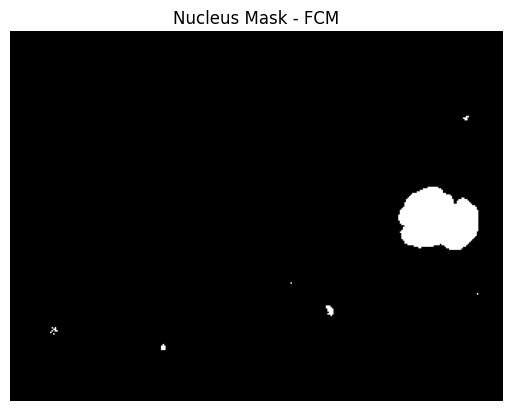

In [131]:
cluster_a_means_f = []

for i in range(4):
    cluster_a_means_f.append(
        np.mean(lab[:,:,1][segmented_fcm == i])
    )

nucleus_cluster_f = np.argmax(cluster_a_means_f)

print("Nucleus cluster (FCM):", nucleus_cluster_f)

nucleus_mask_fcm = (segmented_fcm == nucleus_cluster_f)

plt.imshow(nucleus_mask_fcm, cmap="gray")
plt.title("Nucleus Mask - FCM")
plt.axis("off")
plt.show()

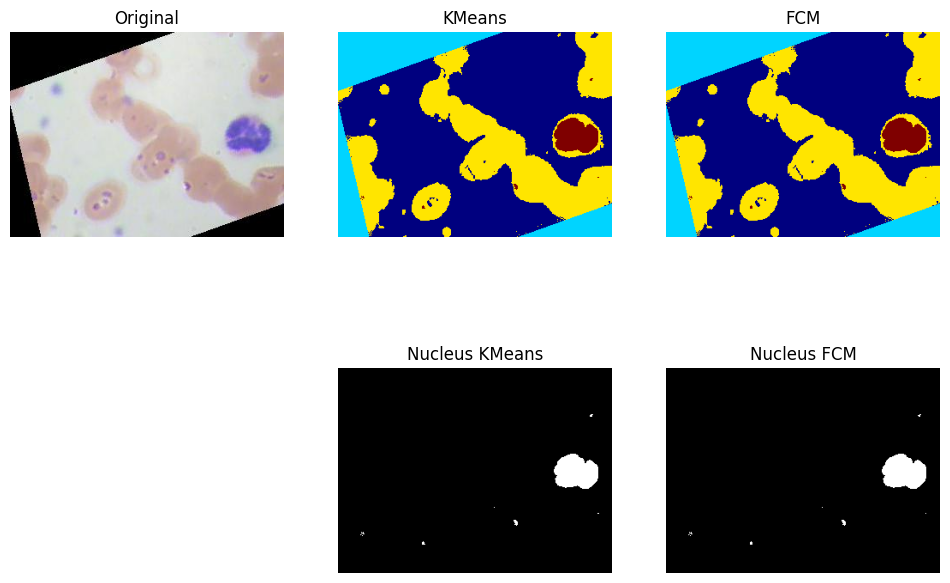

In [132]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(segmented_kmeans, cmap="jet")
plt.title("KMeans")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(segmented_fcm, cmap="jet")
plt.title("FCM")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(nucleus_mask_kmeans, cmap="gray")
plt.title("Nucleus KMeans")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(nucleus_mask_fcm, cmap="gray")
plt.title("Nucleus FCM")
plt.axis("off")

plt.show()

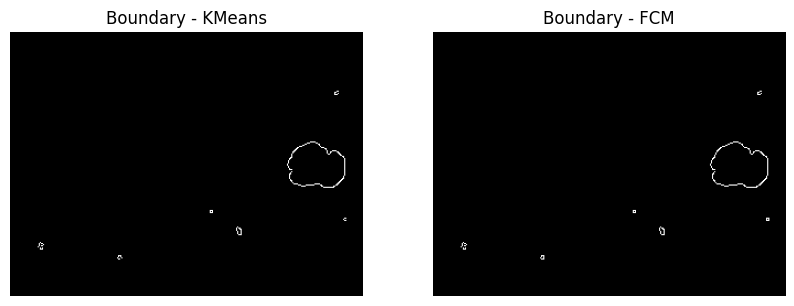

In [133]:
edges_k = cv2.Canny(nucleus_mask_kmeans.astype(np.uint8)*255, 50, 150)
edges_f = cv2.Canny(nucleus_mask_fcm.astype(np.uint8)*255, 50, 150)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(edges_k, cmap="gray")
plt.title("Boundary - KMeans")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges_f, cmap="gray")
plt.title("Boundary - FCM")
plt.axis("off")

plt.show()

In [134]:
from IPython.display import Markdown, display
import numpy as np

area_k = np.sum(nucleus_mask_kmeans)
area_f = np.sum(nucleus_mask_fcm)
diff = abs(area_k - area_f)

display(Markdown(f"""
## Quantitative Comparison

- **KMeans nucleus area:** {area_k} pixels  
- **FCM nucleus area:** {area_f} pixels  
- **Difference:** {diff} pixels  

The small difference indicates both methods successfully segment the nucleus.  
FCM produces slightly smoother boundaries due to soft clustering.
"""))


## Quantitative Comparison

- **KMeans nucleus area:** 1686 pixels  
- **FCM nucleus area:** 1681 pixels  
- **Difference:** 5 pixels  

The small difference indicates both methods successfully segment the nucleus.  
FCM produces slightly smoother boundaries due to soft clustering.


In [135]:
intersection = np.logical_and(nucleus_mask_kmeans, nucleus_mask_fcm).sum()
dice = (2 * intersection) / (np.sum(nucleus_mask) + np.sum(nucleus_mask_fcm))
print("Dice similarity between KMeans and FCM:", dice)

Dice similarity between KMeans and FCM: 0.5952549575070821


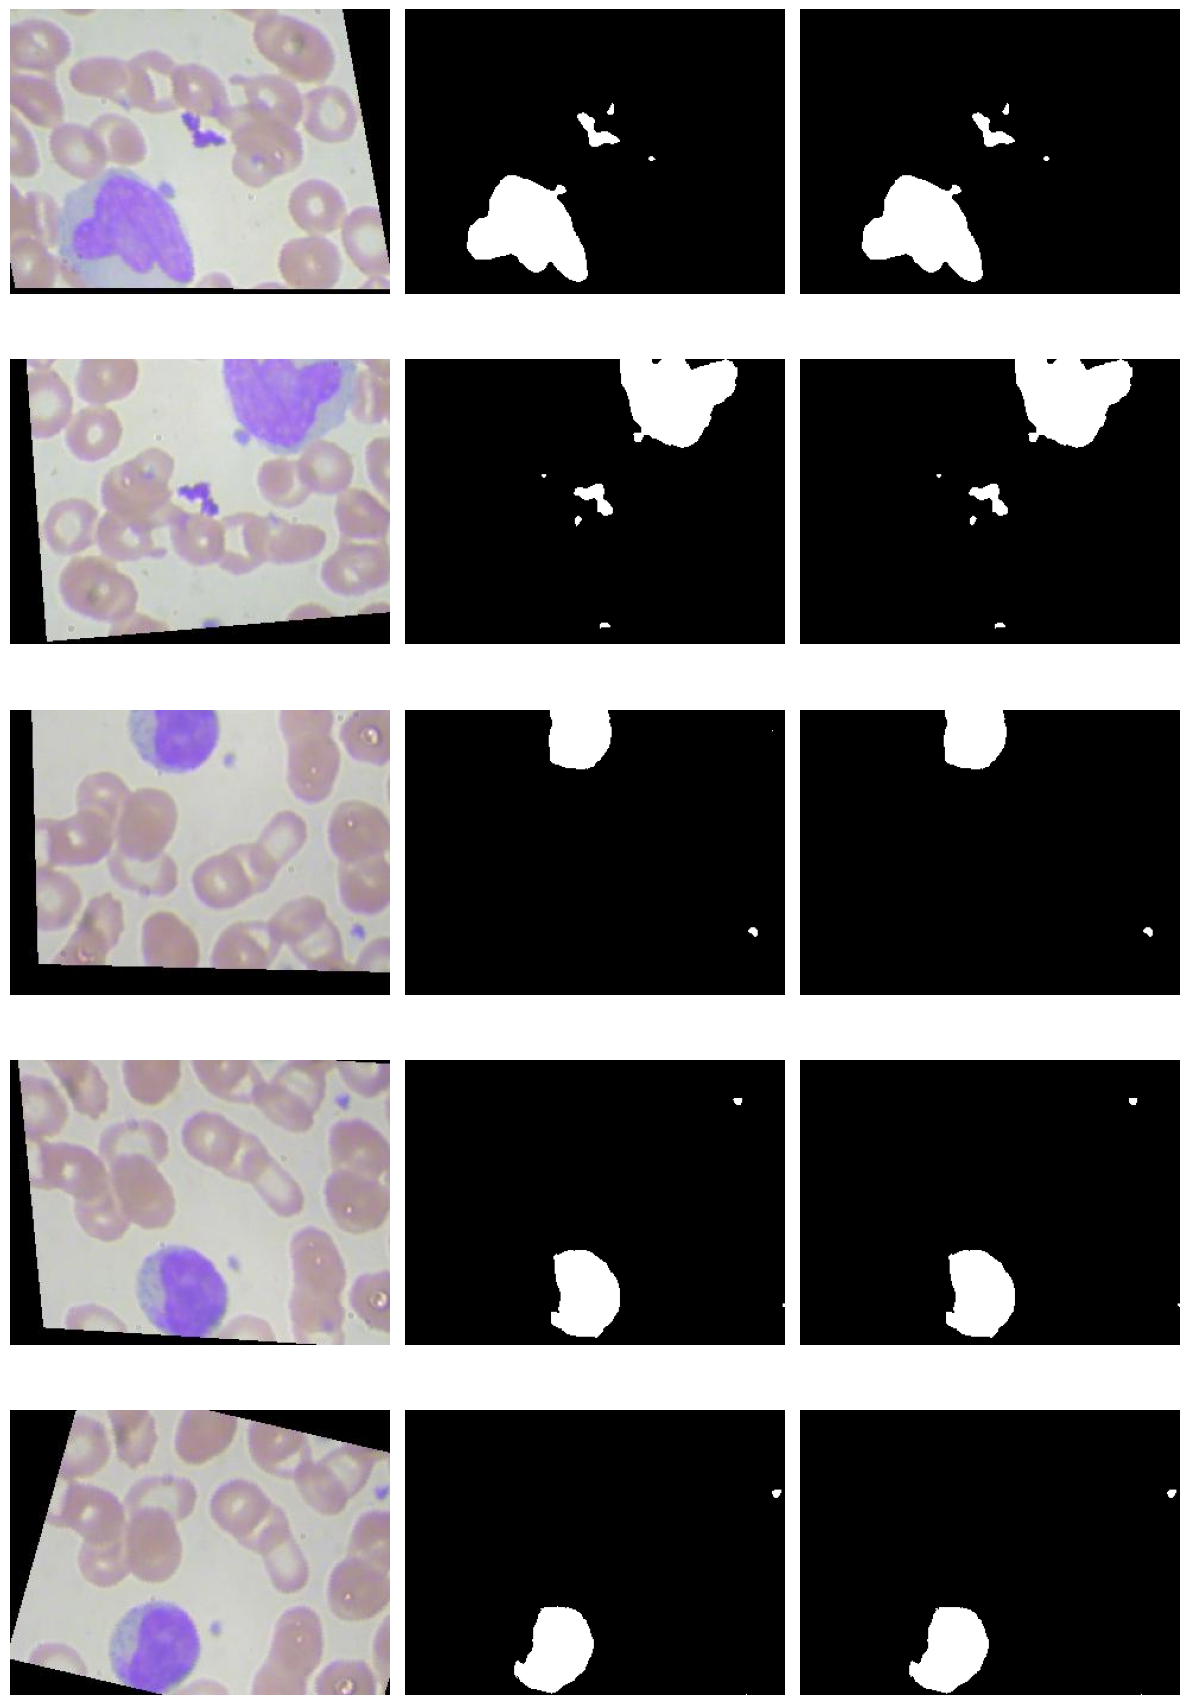

Average KMeans area: 4177.6
Average FCM area: 4171.2
Average Difference: 6.4


In [137]:
import glob

image_paths = glob.glob("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE/*.jpeg")[:5]

areas_k = []
areas_f = []

plt.figure(figsize=(12, 18))

for i, path in enumerate(image_paths):
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    
    pixels = lab.reshape((-1,3)).astype(np.float32)
    
    # KMeans
    kmeans = KMeans(n_clusters=4, random_state=42)
    labels_k = kmeans.fit_predict(pixels)
    segmented_k = labels_k.reshape(lab.shape[:2])
    
    cluster_a = [np.mean(lab[:,:,1][segmented_k == j]) for j in range(4)]
    nucleus_k = np.argmax(cluster_a)
    mask_k = (segmented_k == nucleus_k)
    
    # FCM
    pixels_T = pixels.T
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(pixels_T, 4, 2, 0.005, 500)
    labels_f = np.argmax(u, axis=0)
    segmented_f = labels_f.reshape(lab.shape[:2])
    
    cluster_a_f = [np.mean(lab[:,:,1][segmented_f == j]) for j in range(4)]
    nucleus_f = np.argmax(cluster_a_f)
    mask_f = (segmented_f == nucleus_f)
    
    areas_k.append(np.sum(mask_k))
    areas_f.append(np.sum(mask_f))
    
    # Plot
    plt.subplot(5,3,i*3+1)
    plt.imshow(img)
    plt.axis("off")
    
    plt.subplot(5,3,i*3+2)
    plt.imshow(mask_k, cmap="gray")
    plt.axis("off")
    
    plt.subplot(5,3,i*3+3)
    plt.imshow(mask_f, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Average KMeans area:", np.mean(areas_k))
print("Average FCM area:", np.mean(areas_f))
print("Average Difference:", np.mean(np.abs(np.array(areas_k)-np.array(areas_f))))

# Conclusion

- K-Means performs hard clustering.
- FCM performs soft clustering using membership values.
- FCM produces smoother and more continuous boundaries.
- K-Means is faster but slightly rigid at edges.
- Soft clustering is more suitable for medical image segmentation where boundary uncertainty exists.